# Pharma Sales Exploration

This notebook is for inspecting the raw sales CSV files and understanding the time-series pattern before any forecasting model is trained.

Goals:
- load the CSV files from the data folder
- inspect the columns and date structure
- visualize overall sales by drug category over time
- identify whether strong seasonality is present


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
DATA_DIR.exists()


True

In [16]:
# Load the daily sales data
sales_daily = pd.read_csv(DATA_DIR / 'salesdaily.csv')

sales_daily.head()


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [17]:
# Inspect columns and types
sales_daily.info()


<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [18]:
# Convert the date column into a proper datetime format
sales_daily['datum'] = pd.to_datetime(sales_daily['datum'], format='%m/%d/%Y')

# Keep the sales columns and sort by time
sales_daily = sales_daily[['datum'] + [c for c in sales_daily.columns if c not in ['datum', 'Year', 'Month', 'Hour', 'Weekday Name']]]
sales_daily = sales_daily.sort_values('datum').reset_index(drop=True)

sales_daily.head()


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0


In [19]:
# Create a long-form table for plotting
sales_long = sales_daily.melt(id_vars='datum', var_name='category', value_name='sales')

sales_long.head()


,datum,category,sales
0,2014-01-02,M01AB,0.0
1,2014-01-03,M01AB,8.0
2,2014-01-04,M01AB,2.0
3,2014-01-05,M01AB,4.0
4,2014-01-06,M01AB,5.0


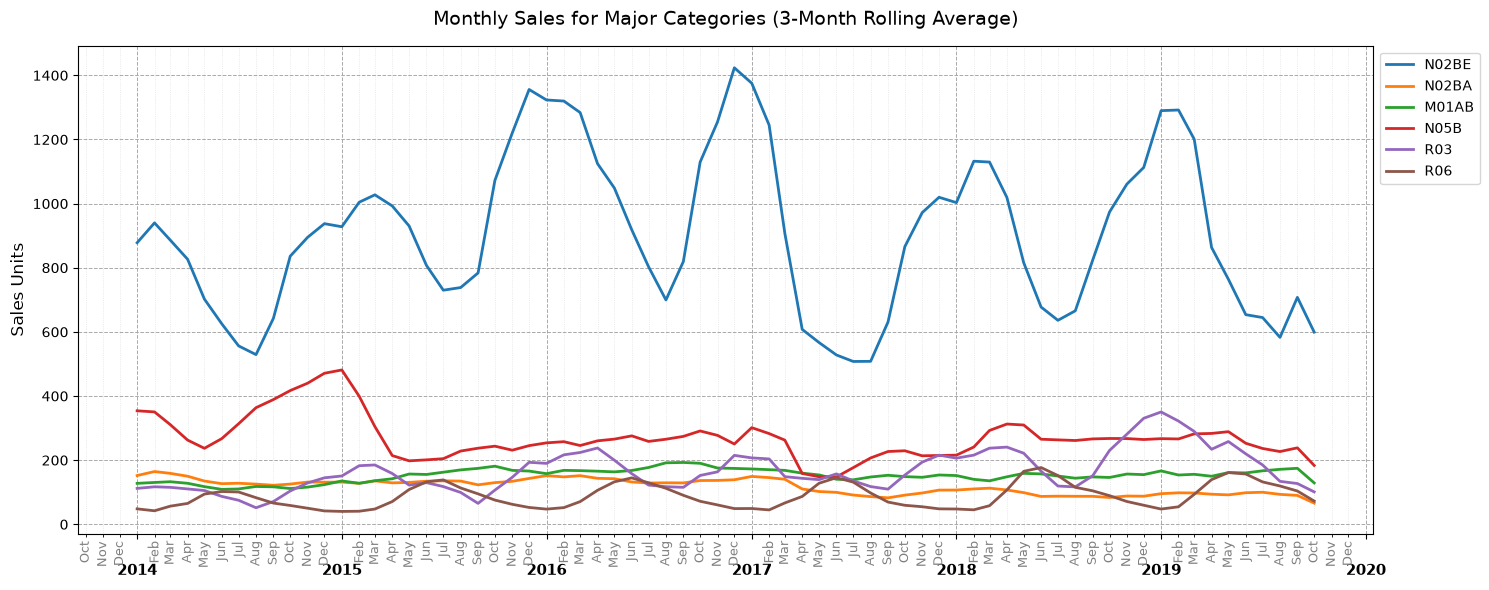

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. CRITICAL FIX: Convert string dates to actual datetime objects
sales_daily['datum'] = pd.to_datetime(sales_daily['datum'])

# 2. Aggregate to monthly sales so trends and seasonality are easier to see
monthly = sales_daily.set_index('datum').resample('MS').sum()
monthly_smooth = monthly.rolling(3, min_periods=1).mean()

# 3. Focus on a few categories to reduce clutter
selected_categories = ['N02BE', 'N02BA', 'M01AB', 'N05B', 'R03', 'R06']

fig, ax = plt.subplots(figsize=(15, 6)) # Gives precise axis control

for category in selected_categories:
    ax.plot(monthly_smooth.index, monthly_smooth[category], label=category, linewidth=2)

# --- PROFESSIONAL X-AXIS FORMATTING ---
# Major ticks: Show the Year clearly at the start of each year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('\n%Y')) # \n moves the year to a second line

# Minor ticks: Label every single month by its abbreviated name (Jan, Feb, etc.)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

# Style the labels so they look clean and don't overlap
plt.setp(ax.get_xminorticklabels(), rotation=90, fontsize=9, color='gray') 
plt.setp(ax.get_xmajorticklabels(), fontsize=11, weight='bold', color='black') 

# Add subtle grid lines for both months and years to make reading patterns easy
ax.grid(True, which='minor', color='gainsboro', linestyle=':', linewidth=0.5)
ax.grid(True, which='major', color='darkgray', linestyle='--', linewidth=0.7)
# -------------------------------------

plt.title('Monthly Sales for Major Categories (3-Month Rolling Average)', fontsize=14, pad=15)
plt.ylabel('Sales Units', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
from prophet import Prophet

# 1. Aggregate daily data to monthly totals
# Assuming your daily dataframe is named 'sales_daily' and has a 'datum' column
monthly = sales_daily.set_index('datum').resample('MS').sum().reset_index()

# 2. Define categories and setup storage
categories = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
all_forecasts = {}
models = {}

# Define the train/validation cutoff
# Leaving the last 12 months for validation is typical if data goes up to mid-2019
train_end = '2018-06-30' 

print("Starting per-category training loop...")

# 3. Loop over categories
for cat in categories:
    print(f"Training model for category: {cat}...")
    
    # Prepare DataFrame for Prophet (requires columns 'ds' and 'y')
    df_cat = monthly[['datum', cat]].rename(columns={'datum': 'ds', cat: 'y'})
    
    # Split into train and validation sets
    train_df = df_cat[df_cat['ds'] <= train_end]
    val_df = df_cat[df_cat['ds'] > train_end]
    
    # Initialize and fit the Prophet model
    # Since data is monthly, we explicitly disable weekly and daily seasonality
    model = Prophet(
        yearly_seasonality=True, 
        weekly_seasonality=False, 
        daily_seasonality=False
    )
    model.fit(train_df)
    
    # Forecast the next 12 months (periods=12, freq='MS' for Monthly Start)
    future = model.make_future_dataframe(periods=12, freq='MS')
    forecast = model.predict(future)
    
    # Store the results for later evaluation
    models[cat] = model
    all_forecasts[cat] = {
        'forecast': forecast,
        'train_actuals': train_df,
        'val_actuals': val_df
    }

print("Loop completed successfully!")

22:37:57 - cmdstanpy - INFO - Chain [1] start processing


Starting per-category training loop...
Training model for category: M01AB...


22:37:57 - cmdstanpy - INFO - Chain [1] done processing
22:37:57 - cmdstanpy - INFO - Chain [1] start processing


Training model for category: M01AE...


22:37:58 - cmdstanpy - INFO - Chain [1] done processing
22:37:58 - cmdstanpy - INFO - Chain [1] start processing


...

Training model for category: R03...


22:38:00 - cmdstanpy - INFO - Chain [1] done processing
22:38:00 - cmdstanpy - INFO - Chain [1] start processing


Training model for category: R06...


22:38:01 - cmdstanpy - INFO - Chain [1] done processing


Loop completed successfully!


           ds         yhat   yhat_lower   yhat_upper
54 2018-07-01   594.262613   387.453929   796.525566
55 2018-08-01   661.977175   452.402522   854.817061
56 2018-09-01   892.218904   687.766743  1088.474873
57 2018-10-01  1341.422938  1145.371478  1534.123099
58 2018-11-01   978.623004   787.807485  1190.256556
59 2018-12-01  1149.578656   946.119971  1344.746847
60 2019-01-01  1190.726992   995.911079  1403.336422
61 2019-02-01  1068.232197   866.630323  1279.295240
62 2019-03-01   894.005204   695.484124  1096.087348
63 2019-04-01   765.937046   563.086270   968.645994
64 2019-05-01   607.510409   409.229531   823.394243
65 2019-06-01   601.716554   399.337383   814.014403


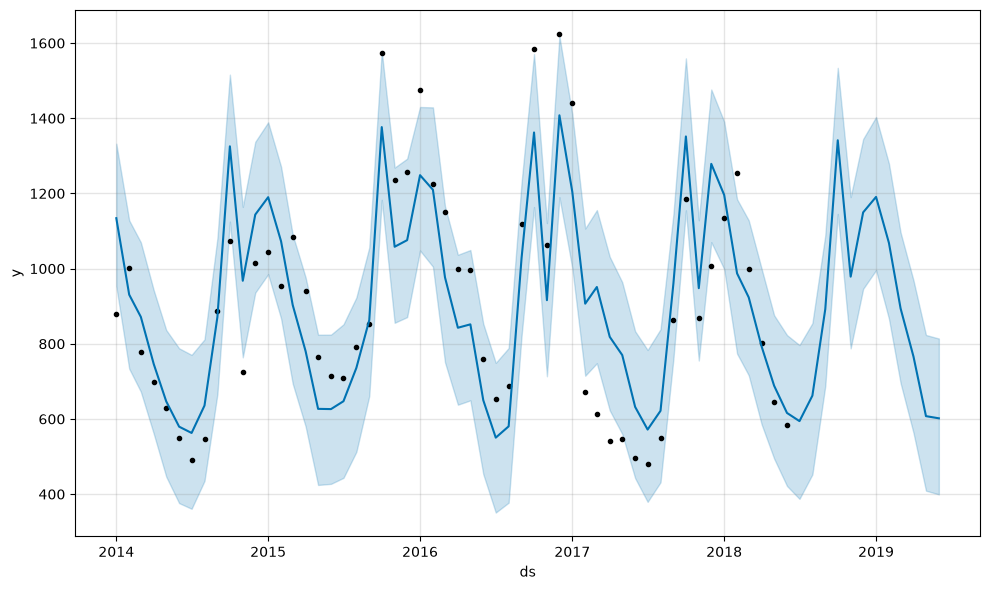

In [22]:
# Quick look at the N02BE forecast vs actuals
n02be_data = all_forecasts['N02BE']
forecast_df = n02be_data['forecast']

# Filter forecast to look at the validation period
validation_forecast = forecast_df[forecast_df['ds'] > train_end][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
print(validation_forecast)

# Optional: Plot it to visually inspect it
models['N02BE'].plot(forecast_df);

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(f"{'Category':<10} | {'Mean Actual':<12} | {'MAE':<10} | {'RMSE':<10} | {'Error %':<10}")
print("-" * 60)

performance_metrics = {}

for cat, data in all_forecasts.items():
    # 1. Pull actuals and predictions for the validation period
    actuals_df = data['val_actuals']
    forecast_df = data['forecast']
    
    # Align them on the 'ds' (date) column so we compare the exact same months
    comparison_df = pd.merge(actuals_df, forecast_df[['ds', 'yhat']], on='ds')
    
    # 2. Calculate errors
    y_actual = comparison_df['y']
    y_pred = comparison_df['yhat']
    
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    
    # Calculate a rough percentage error relative to the scale of sales
    mean_actual = y_actual.mean()
    error_pct = (mae / mean_actual) * 100 if mean_actual > 0 else 0
    
    # Store for later analysis
    performance_metrics[cat] = {'mae': mae, 'rmse': rmse, 'error_pct': error_pct}
    
    # 3. Print structured results
    print(f"{cat:<10} | {mean_actual:<12.2f} | {mae:<10.2f} | {rmse:<10.2f} | {error_pct:<.1f}%")

Category   | Mean Actual  | MAE        | RMSE       | Error %   
------------------------------------------------------------
M01AB      | 154.78       | 15.45      | 18.75      | 10.0%
M01AE      | 121.18       | 15.21      | 25.44      | 12.5%
N02BA      | 92.80        | 13.98      | 16.73      | 15.1%
N02BE      | 947.83       | 118.55     | 168.37     | 12.5%
N05B       | 266.37       | 62.20      | 77.83      | 23.4%
N05C       | 21.00        | 7.66       | 9.40       | 36.5%
R03        | 247.86       | 70.75      | 79.53      | 28.5%
R06        | 103.55       | 21.79      | 32.42      | 21.0%


In [24]:
import os
import joblib

# Create the model output folder if it does not exist
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save trained models and forecast data
for cat, data in all_forecasts.items():
    model_path = MODEL_DIR / f'{cat}_prophet.pkl'
    forecast_path = MODEL_DIR / f'{cat}_forecast.csv'

    joblib.dump(models[cat], model_path)
    data['forecast'].to_csv(forecast_path, index=False)

print(f'Saved {len(all_forecasts)} models and forecasts to {MODEL_DIR}')


Saved 8 models and forecasts to ..\models


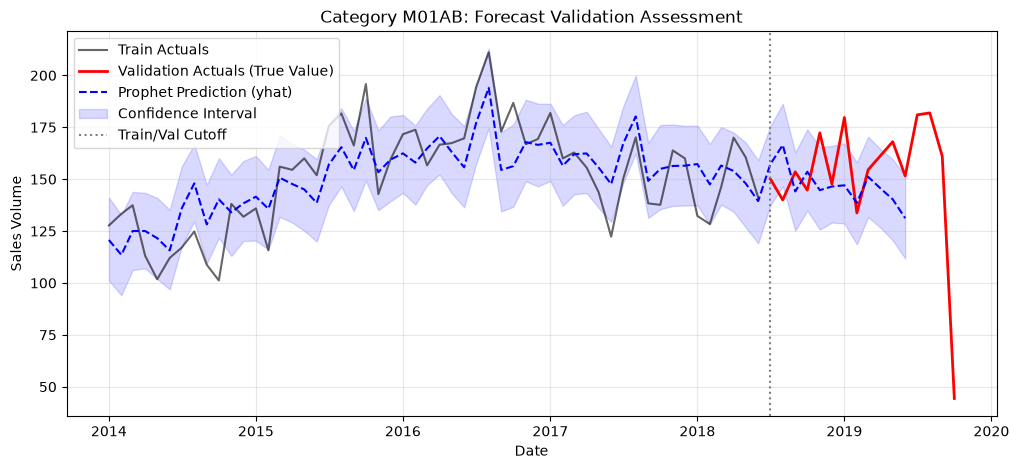

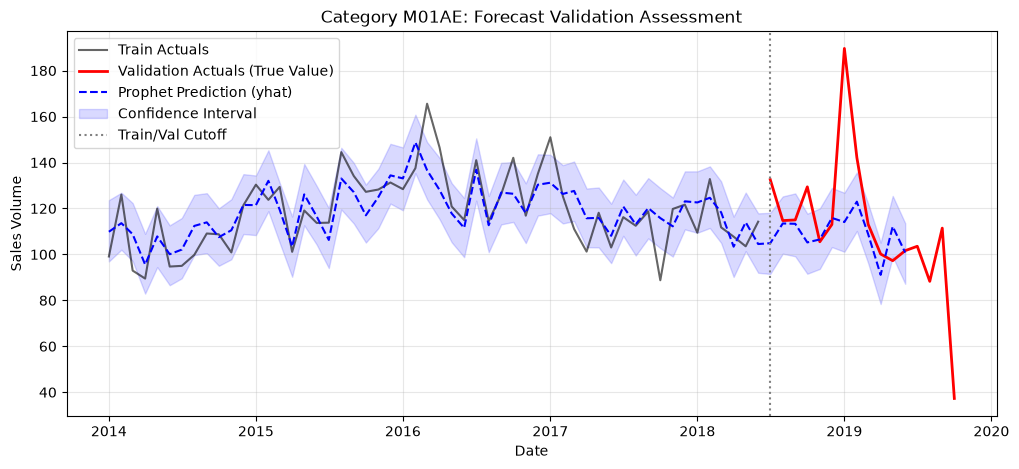

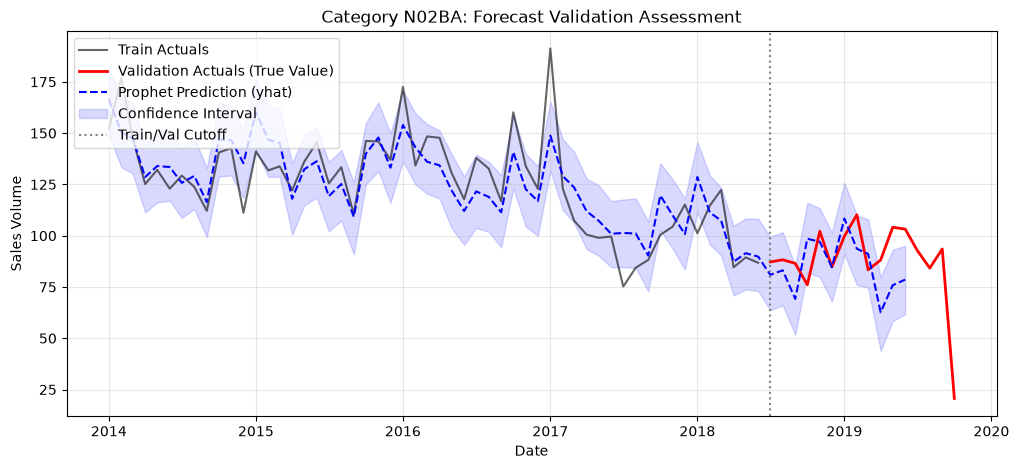

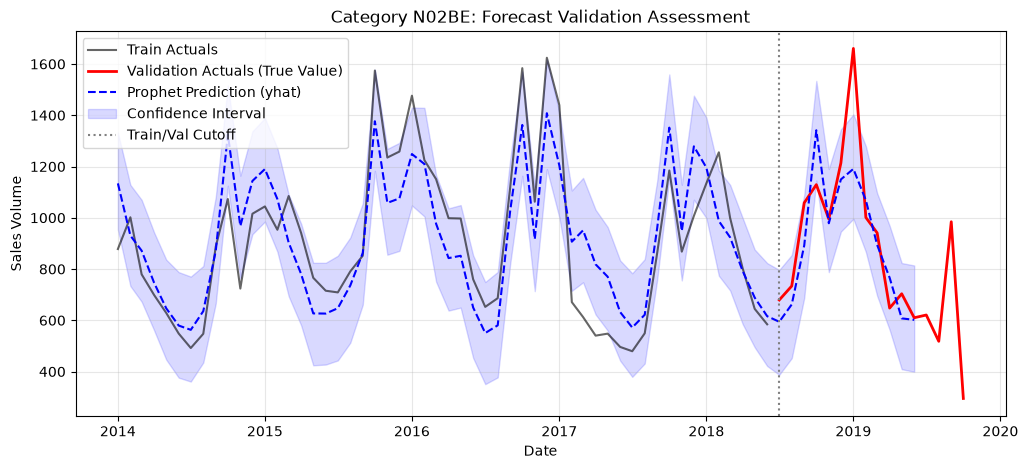

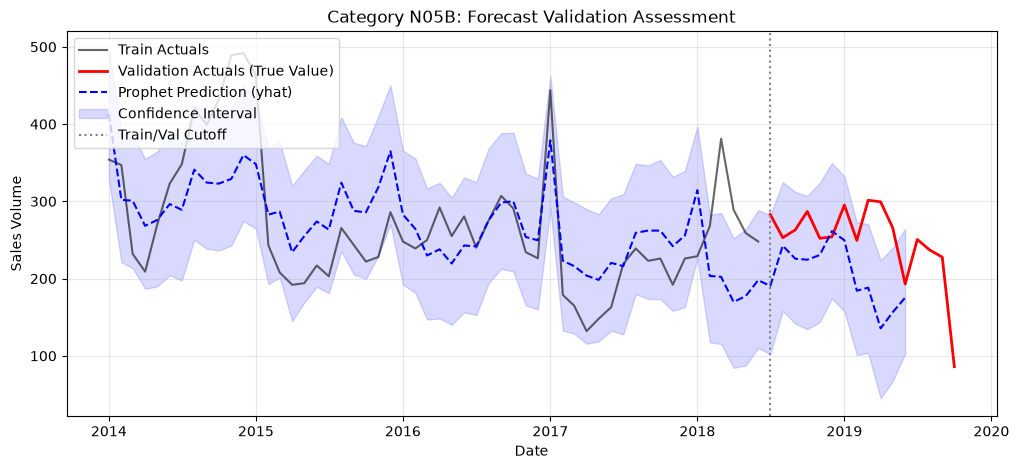

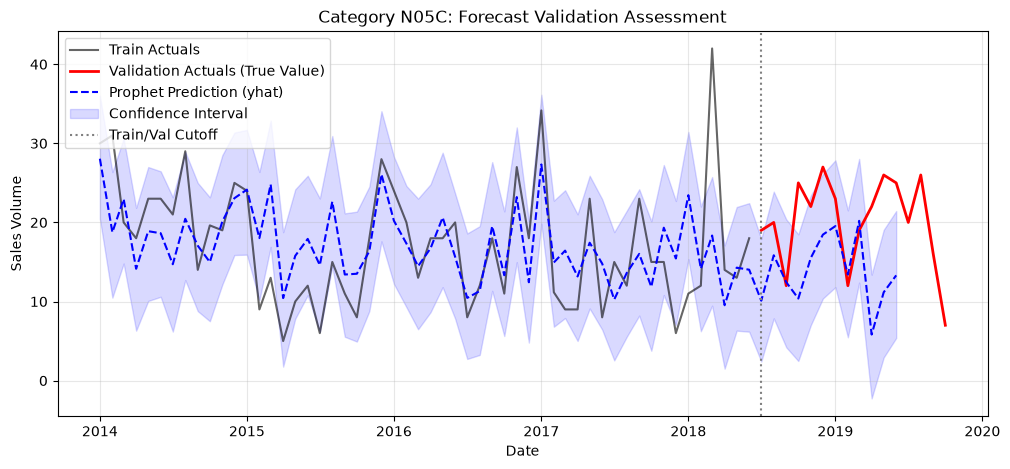

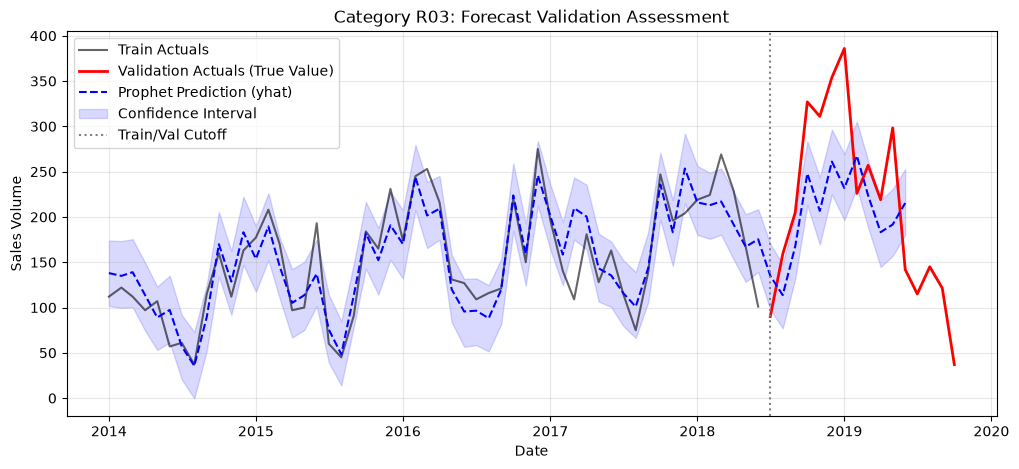

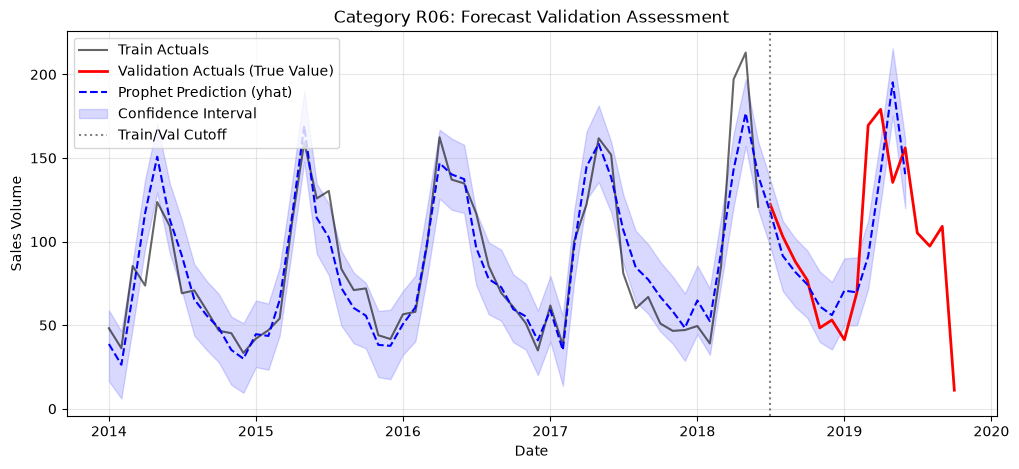

In [25]:
import matplotlib.pyplot as plt

# Loop through each category to visualize actuals vs predictions
for cat, data in all_forecasts.items():
    # 1. Pull data pieces
    train_df = data['train_actuals']
    val_df = data['val_actuals']
    forecast_df = data['forecast']
    
    # 2. Initialize the plot
    plt.figure(figsize=(12, 5))
    
    # Plot historical training points and actual validation points
    plt.plot(train_df['ds'], train_df['y'], label='Train Actuals', color='black', alpha=0.6)
    plt.plot(val_df['ds'], val_df['y'], label='Validation Actuals (True Value)', color='red', linewidth=2)
    
    # Plot Prophet's prediction line across both periods
    plt.plot(forecast_df['ds'], forecast_df['yhat'], label='Prophet Prediction (yhat)', color='blue', linestyle='--')
    
    # Fill in the confidence interval gap
    plt.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'], 
                     color='blue', alpha=0.15, label='Confidence Interval')
    
    # Add vertical line showing exactly where the training stopped and validation began
    plt.axvline(pd.to_datetime(train_end), color='gray', linestyle=':', label='Train/Val Cutoff')
    
    # 3. Aesthetics
    plt.title(f"Category {cat}: Forecast Validation Assessment")
    plt.xlabel("Date")
    plt.ylabel("Sales Volume")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Show plot clean and crisp
    plt.show()

In [26]:
import joblib

# Save trained models and forecasts
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for cat, data in all_forecasts.items():
    model_path = MODEL_DIR / f'{cat}_prophet.pkl'
    forecast_path = MODEL_DIR / f'{cat}_forecast.csv'
    joblib.dump(models[cat], model_path)
    data['forecast'].to_csv(forecast_path, index=False)

print(f"Saved {len(all_forecasts)} models and forecasts to {MODEL_DIR}")


Saved 8 models and forecasts to ..\models
